# Tiền xử lý dữ liệu Pima Indians Diabetes

## 1. Import các thư viện cần thiết

In [25]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

# preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold

# algorithms
from sklearn.tree import DecisionTreeClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
import sklearn

# metrics
from sklearn.metrics import accuracy_score , ConfusionMatrixDisplay, confusion_matrix

import warnings

## 2. Đọc file dữ liệu đã dọn dẹp

In [26]:
dataFrame = pd.read_csv("../exps/data/cleaned_data.csv")

## 3. Hiển thị dữ liệu

#### 3.1. Hiển thị trên từng tính chất đơn (Univariate Plots)

#### Biểu đồ Histogram

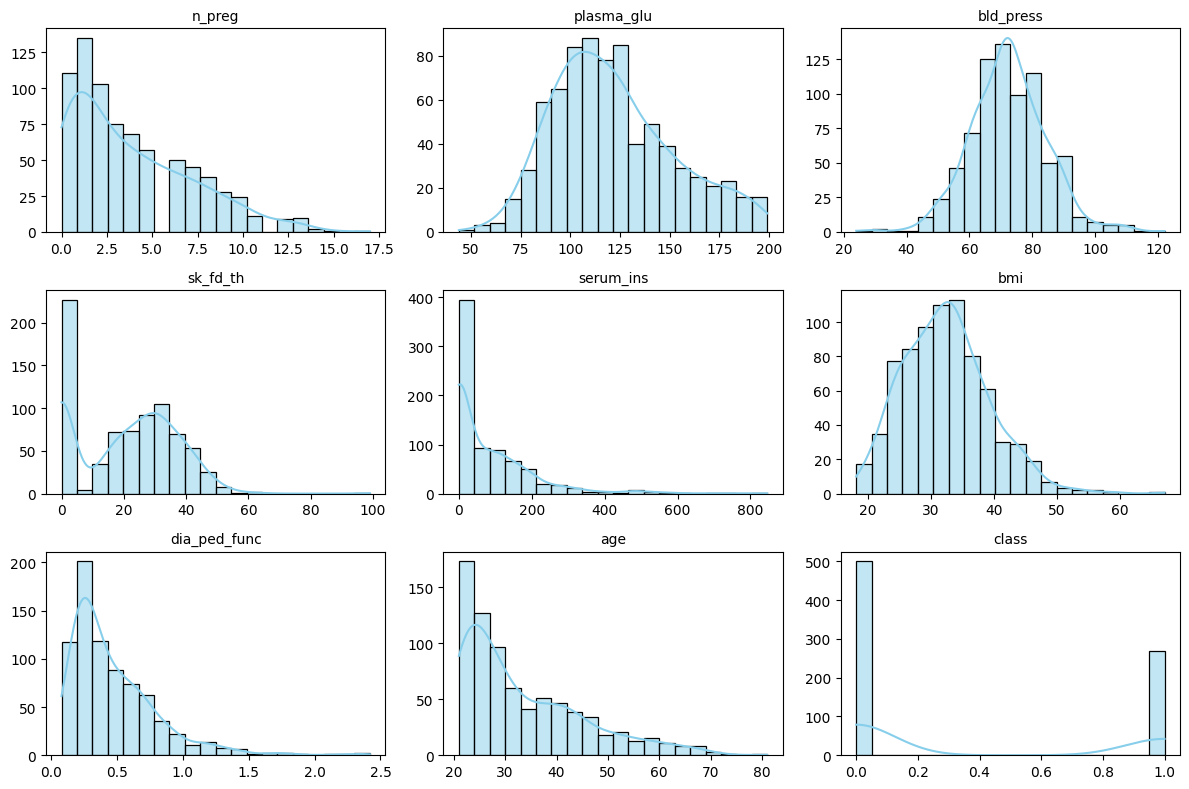

In [27]:
# Tạo lưới biểu đồ
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

# Lặp qua các cột trong dataframe
for i, col in enumerate(dataFrame.columns):
    sns.histplot(dataFrame[col], bins=20, kde=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig("fig_hist.png")
plt.show()

##### Biểu đồ Histogram phân phối theo số lượng phân bố lớp class.

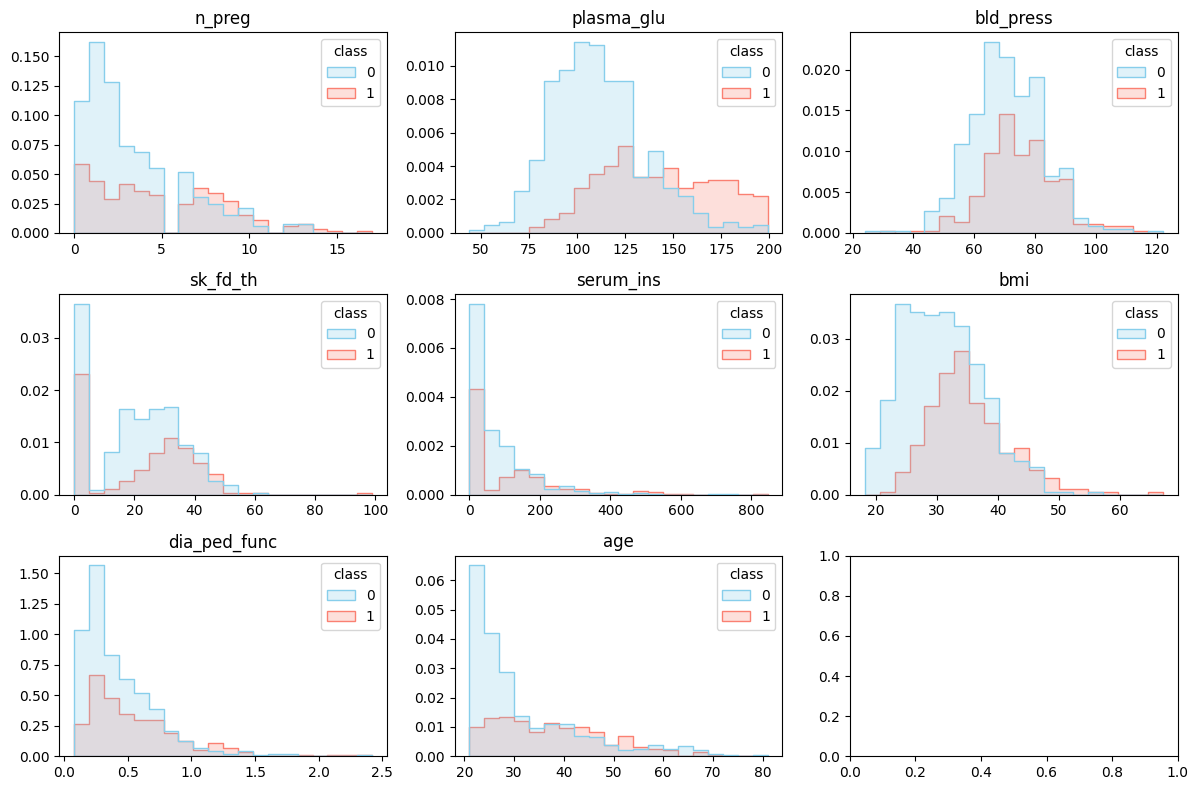

In [28]:
# Tạo lưới biểu đồ
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

cols = [col for col in dataFrame.columns if col != 'class']

for i, col in enumerate(cols[:8]):
    sns.histplot(
        data=dataFrame,
        x=col,
        hue='class',        
        bins=20,
        palette={0: "skyblue", 1: "salmon"}, 
        ax=axes[i],
        element="step",    
        stat="density"  
    )
    axes[i].set_title(f"{col}")
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig("fig_hist_by_class.png", dpi=300)
plt.show()

##### Biểu đồ mật độ

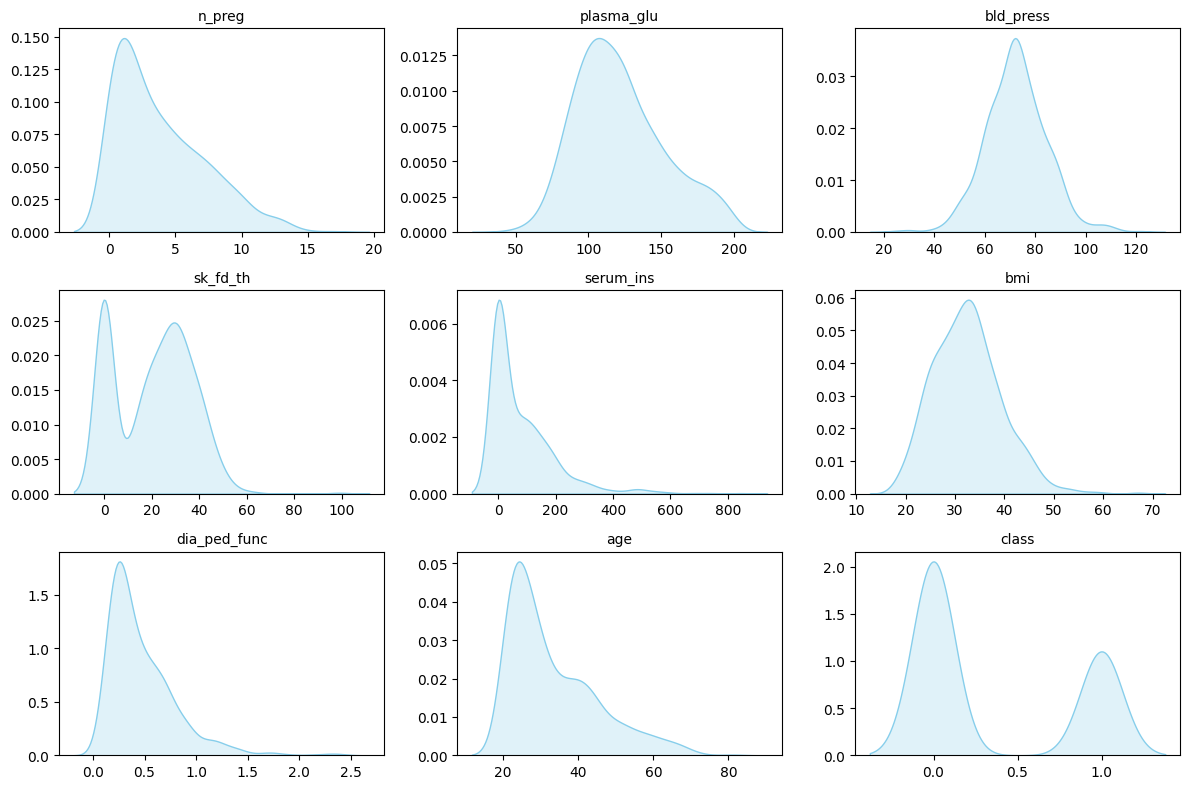

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(dataFrame.columns):
    sns.kdeplot(dataFrame[col], fill=True, color='skyblue', ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.savefig("fig_dens.png")
plt.show()

##### Biểu đồ box plot

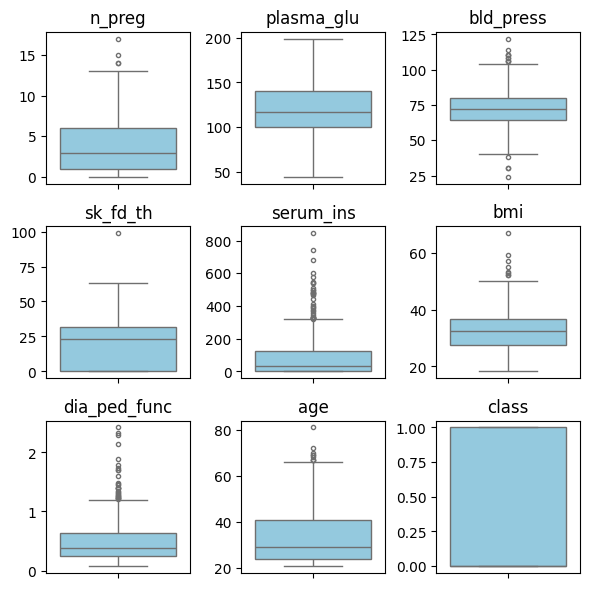

In [30]:
fig, axes = plt.subplots(3, 3, figsize=(6, 6))
axes = axes.flatten()

for i, col in enumerate(dataFrame.columns):
    sns.boxplot(y=dataFrame[col], ax=axes[i], color="skyblue", fliersize=3, linewidth=1)
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")

for j in range(i + 1, 3 * 3):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("fig_box.png")
plt.show()

**Nhận xét**: 
+ Tính chất plasma_glu, bmi có dạng phân bố gần chuẩn.
+ Tính chất bld_press có dạng phân bố gần chuẩn nhưng có nhiều giá trị ngoại lai ở 0.
+ Tính chất age, n_preg, sk_fd_th lệch phải, cần được biến đổi.
+ Tính chất dia_ped_func, serum_ins lệch phải và có rất nhiều giá trị ngoại lai.

#### 3.2. Hiển thị nhiều tính chất (Multivariate Plots)

#### **Mối tương quan giữa các tính chất (Correlations)** 
Sự tương quan (correlation) đề cập đến mối quan hệ giữa hai biến và cách chúng có thể có hoặc không cùng nhau thay đổi.

##### Dùng Heatmap

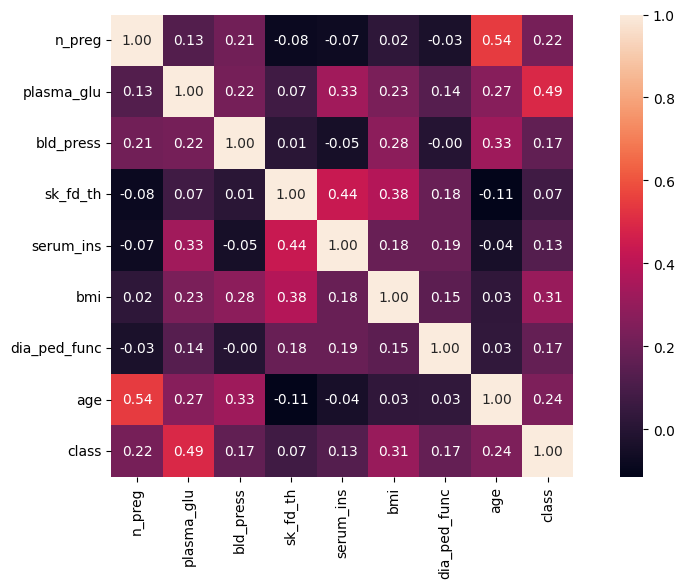

In [31]:
corrMat = dataFrame.corr()
plt.subplots(figsize=(12, 6))
sns.heatmap(corrMat, annot = True, fmt='.2f', annot_kws={'size': 10}, vmax=1.0, square=True)
plt.savefig("fig_corr.png")

##### Scatter Plot giữa 2 tính chất theo class

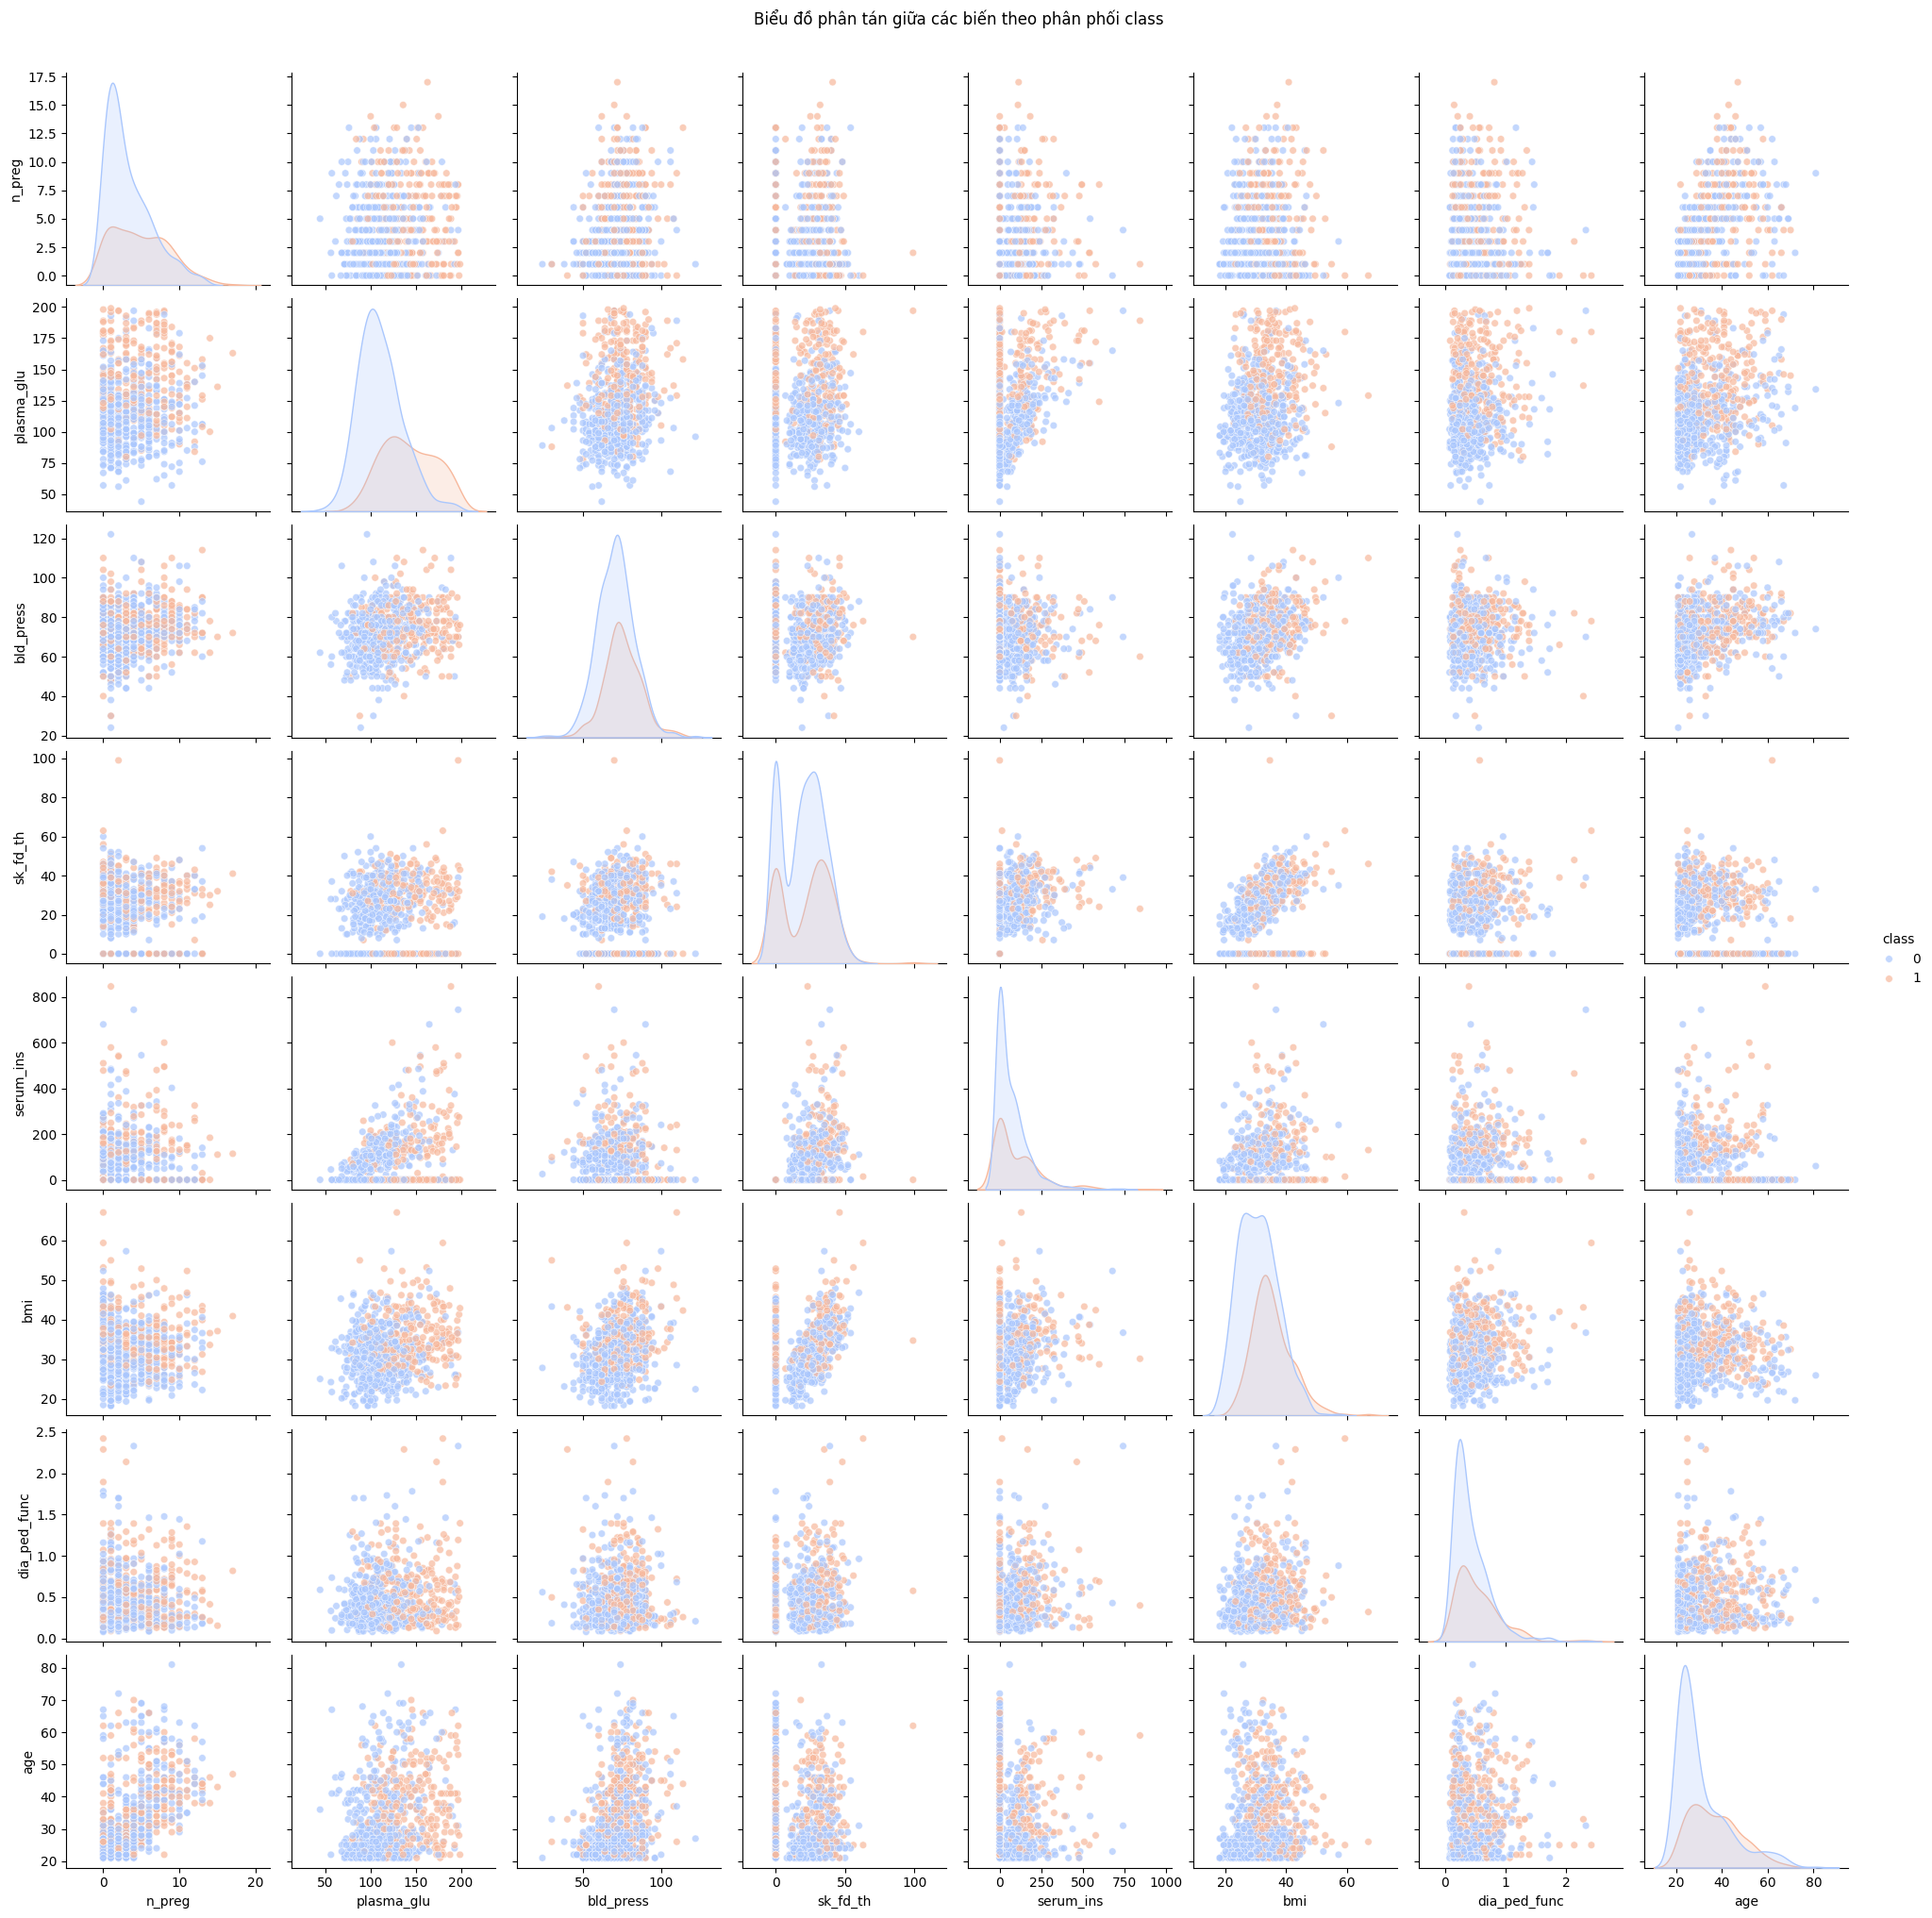

In [32]:

sns.pairplot(
    data=dataFrame,
    vars=[col for col in dataFrame.columns if col != 'class'],  
    hue='class',       
    palette='coolwarm',
    diag_kind='kde',     
    plot_kws={'alpha': 0.7, 's': 30}
)

plt.suptitle("Biểu đồ phân tán giữa các biến theo phân phối class", y=1.02)
plt.savefig("fig_scatter.png")
plt.show()

**Nhận xét**:
+ Tương quan giữa các tính chất với class:
   + plasma_glu (0.47): Mạnh nhất, cho thấy nồng độ glucose huyết tương có ảnh hưởng rõ rệt đến khả năng mắc tiểu đường.
   + bmi	(0.31): Cũng khá cao – chỉ số BMI cao làm tăng nguy cơ mắc bệnh.
   + age	(0.24): Người lớn tuổi có nguy cơ cao hơn.
   + n_preg (0.22): Phụ nữ mang thai nhiều lần có nguy cơ cao hơn.
   + dia_ped_func, bld_press (0.17): Tương quan yếu – chỉ ảnh hưởng nhẹ.
   + serum_ins, sk_fd_th (0.07–0.13): Gần như không đáng kể.
+ Tương quan giữa các tính chất độc lập (không phải class): 
   + age <-> n_preg (0.54): Tương quan khá cao, phụ nữ lớn tuổi thường có nhiều lần mang thai hơn.
   + sk_fd_th <-> serum_ins (0.44): Có thể cùng phản ánh tình trạng chuyển hóa insulin.
   + sk_fd_th <-> bmi (0.38): Hợp lý, vì độ dày da và chỉ số BMI đều phản ánh lượng mỡ cơ thể.

**Như vậy, các đặc trưng mạnh nhất là plasma_glu, bmi, age và n_preg.**

## 4. Tiền xử lý dữ liệu

### 4.1. Thực hiện chọn đặc trưng và chia dữ liệu.
Dữ liệu được chia thành 2 tập train và test với tỷ lệ chia train/validation/test là 85/15.
Các tham số được chọn là n_preg, plasma_glu, bmi, age, bld_press, dia_ped_func.

In [33]:
X = dataFrame[["n_preg", "plasma_glu", "bmi", "age", "bld_press", "dia_ped_func"]] 
y = dataFrame["class"]

# 85% train, 15% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

### 4.2. Biến đổi dữ liệu
Dữ liệu được biến đổi và chuẩn hóa.

In [34]:
# Logarithmic transformation
X_train = np.log1p(X_train)
X_test = np.log1p(X_test)

# Standardize features.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 4.3. Lưu dữ liệu train và test đã chia và chuẩn hóa.

In [35]:
np.save('../exps/data/X_train_scaled', X_train)
np.save('../exps/data/X_test_scaled', X_test)
np.save('../exps/data/y_train', y_train)
np.save('../exps/data/y_test', y_test)

## 5. Lưu dưới dạng HTML.

In [36]:
import nbformat
from nbconvert import HTMLExporter

# load notebook
nb = nbformat.read("preprocessing.ipynb", as_version=4)

# tạo exporter
html_exporter = HTMLExporter()
html_exporter.template_name = 'lab'

(body, resources) = html_exporter.from_notebook_node(nb)

# ghi file HTML
with open("preprocessing.html", "w", encoding="utf-8") as f:
    f.write(body)

# Kết thúc